### Load Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### Load and Inspect Data

In [82]:
# Load Data
df = pd.read_csv("../datasets/processed/cleaned_data.csv")
display(df.head())

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,type
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,train
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,train
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,4,3,4,4,4,5,0,0.0,satisfied,train
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,train
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,4,4,3,3,3,0,0.0,satisfied,train


### Encode Categorical Data

In [84]:
df_train = df.copy()
df_train['label'] = df_train['satisfaction'].apply(lambda x:1 if x == 'satisfied' else 0)

encode_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df[encode_cols], columns=encode_cols, dtype=int)

df_train = pd.concat([df_train, df_encoded], axis=1)

display(df_encoded.head())

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,0,1,1,0,0,1,0,0,1
1,0,1,0,1,1,0,1,0,0
2,1,0,1,0,1,0,1,0,0
3,1,0,1,0,1,0,1,0,0
4,0,1,1,0,1,0,1,0,0


In [85]:
# Drop unnecesaary columns
dropped_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
df_train = df_train.drop(dropped_cols, axis=1)

In [86]:
# Create train dataset
X_train = y_train = df_train[df_train['type'] == 'train']
X_train = X_train.drop(['type', 'label'], axis=1)
y_train = y_train['label']

# Create test dataset
X_test = y_test = df_train[df_train['type'] == 'test']
X_test = X_test.drop(['type', 'label'], axis=1)
y_test = y_test['label']

In [87]:
# Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [88]:
# Evaluate model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.965
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14528
           1       0.97      0.95      0.96     11365

    accuracy                           0.97     25893
   macro avg       0.97      0.96      0.96     25893
weighted avg       0.97      0.97      0.97     25893



### Visualize Features

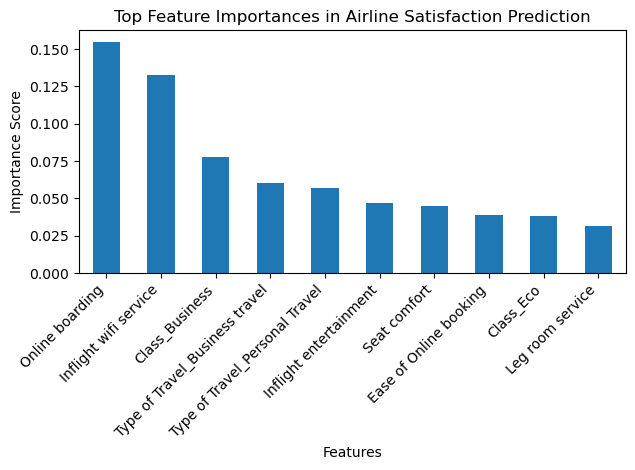

In [54]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X_train.columns
n = min(10, len(importances))

forest_importances = pd.Series(importances, index=feature_names)
forest_importances = forest_importances.sort_values(ascending=False)

fig, ax = plt.subplots()
forest_importances[:n].plot.bar(range(n),importances[indices][:n],ax=ax)
ax.set_title('Top Feature Importances in Airline Satisfaction Prediction')
ax.set_xlabel('Features')
ax.set_ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()

Online boarding expreince appears to be the biggest satisfaction predictor.

### Breakdown by Class

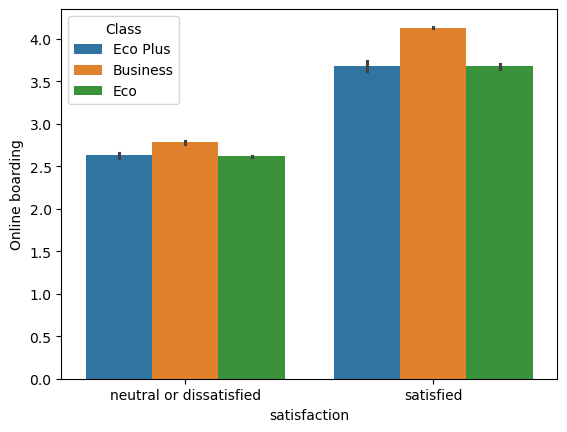

In [81]:
fig, ax = plt.subplots()
sns.barplot(data=df, y='Online boarding', x='satisfaction', hue='Class', ax=ax)
plt.show()

According to the box plot, business class flyers give higher scores for their online boarding experience. However, these higher scores, especially in the neutral or dissatisfied category, suggest business class flyers have a higher standard for satisfaction. Despite a higher average score of 2.75, this did not equate to satisfaction. Economy flyers may forgive a 'good' online boarding experience while business flyers demand 'excelence'.  